In [1]:
import pandas as pd
orders = pd.read_csv("orders.csv")
print(orders.columns)

Index(['order_id', 'user_id', 'weight_kg', 'distance_km', 'express_flag',
       'quantity', 'price', 'shipping_cost'],
      dtype='object')


In [1]:
import pandas as pd
import numpy as np
orders = pd.read_csv("orders.csv")
if "order_date" not in orders.columns:
    rng = np.random.default_rng(42)
    orders["order_date"] = (
        pd.Timestamp("2024-01-01")+pd.to_timedelta(rng.integers(0, 365, len(orders)),unit="D"))
    orders.to_csv("orders.csv", index=False)
    print("column added")
else:
    print("column exists")
print(orders.head())

column exists
   order_id  user_id  weight_kg  distance_km  express_flag  quantity    price  \
0         0     4647       1.23        303.0         False         3   3823.0   
1         1     3774       1.54         68.0         False         1   3539.0   
2         2     2876       2.27        216.0         False         3  18507.0   
3         3     3155       5.26        354.0         False         5   5797.0   
4         4     2066       3.57         92.0          True         2   1004.0   

   shipping_cost  order_date  
0          222.0  2024-02-02  
1          119.0  2024-10-09  
2          171.0  2024-08-26  
3          218.0  2024-06-09  
4          203.0  2024-06-07  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       40000 non-null  int64         
 1   user_id        40000 non-null  int64         
 2   weight_kg      40000 non-null  float64       
 3   distance_km    40000 non-null  float64       
 4   express_flag   40000 non-null  bool          
 5   quantity       40000 non-null  int64         
 6   price          40000 non-null  float64       
 7   shipping_cost  40000 non-null  float64       
 8   order_date     40000 non-null  datetime64[ns]
dtypes: bool(1), datetime64[ns](1), float64(4), int64(3)
memory usage: 2.5 MB


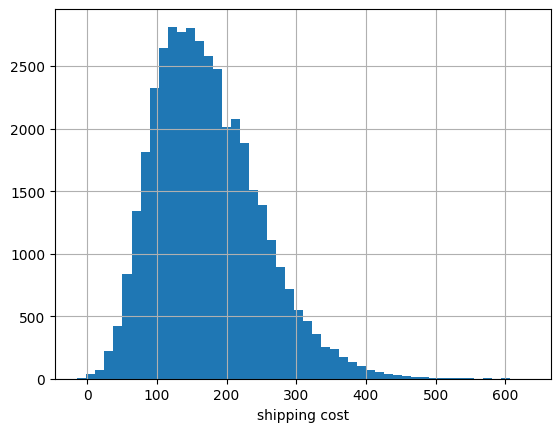

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
orders = pd.read_csv("orders.csv", parse_dates=["order_date"])
orders.info()                      # dtypes + missing counts: ALWAYS your first call
orders.describe()                  # min/max/mean: sanity-check ranges
# Vectorized thinking: no loops. One line computes 8,000 values.
orders["price_per_kg"] = orders["price"] / orders["weight_kg"]
# Group-think: answers business questions in one line
users = pd.read_csv("users.csv")
city_spend = orders.merge(users, on="user_id").groupby("city")["price"].sum()
orders["shipping_cost"].hist(bins=50); plt.xlabel("shipping cost"); plt.show()

exercise Q-1.1

In [ ]:
#1. Load orders.csv; report rows, columns, missing values per column, and the top 5 heaviest orders — in <=6 lines.

In [5]:
orders = pd.read_csv("orders.csv")
print("rows and column",orders.shape)
print("missing values",orders.isnull().sum())
print("5 heaviest orders")
print(orders.nlargest(5, "weight_kg").sort_values("weight_kg", ascending=True))

rows and column (40000, 9)
missing values order_id         0
user_id          0
weight_kg        0
distance_km      0
express_flag     0
quantity         0
price            0
shipping_cost    0
order_date       0
dtype: int64
5 heaviest orders
       order_id  user_id  weight_kg  distance_km  express_flag  quantity  \
24723     24723      155      23.92        196.0         False         2   
788         788     3358      25.11        164.0          True         3   
24191     24191     1303      25.22        108.0          True         1   
6217       6217     3563      26.61        274.0         False         2   
12487     12487     4767      30.03        200.0         False         3   

        price  shipping_cost  order_date  
24723  4081.0          161.0  2024-07-12  
788     981.0          346.0  2024-07-17  
24191  2614.0          236.0  2024-05-22  
6217   4132.0          291.0  2024-03-09  
12487  8536.0          259.0  2024-10-15  


In [ ]:
#2. Add a column is_heavy (weight > 10 kg) without a loop, then compute the mean shipping cost for heavy vs light orders using groupby.

In [7]:
orders["is_heavy"]=orders["weight_kg"]>10
mean_shipping = orders.groupby("weight_kg")["shipping_cost"].mean()
print(mean_shipping)

weight_kg
0.01     155.00
0.03     155.60
0.04     200.25
0.05     126.00
0.06     111.00
          ...  
23.92    161.00
25.11    346.00
25.22    236.00
26.61    291.00
30.03    259.00
Name: shipping_cost, Length: 1596, dtype: float64


In [66]:
#3. Plot shipping_cost vs distance_km as a scatter plot. Describe in one sentence what relationship you see — you will model it in Week 3.

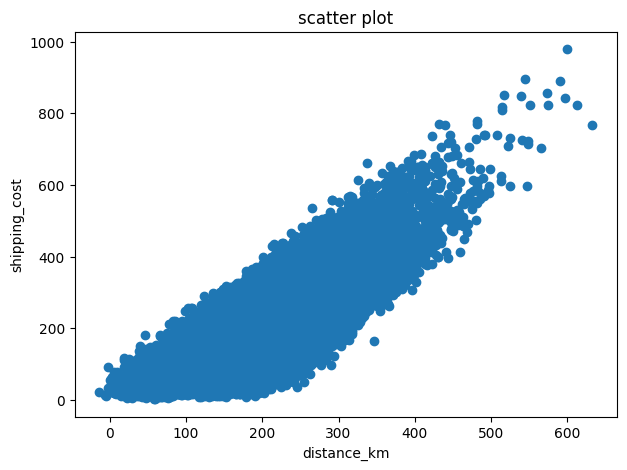

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(orders["shipping_cost"],orders["distance_km"])
plt.title("scatter plot")
plt.xlabel("distance_km")
plt.ylabel("shipping_cost")
plt.show()

1.3

In [30]:
#1. Compute mean, median, std of shipping_cost. Plot the histogram. Is it skewed? Which central measure would you report?

mean 172.693
median 163.0
std 75.1075760472907


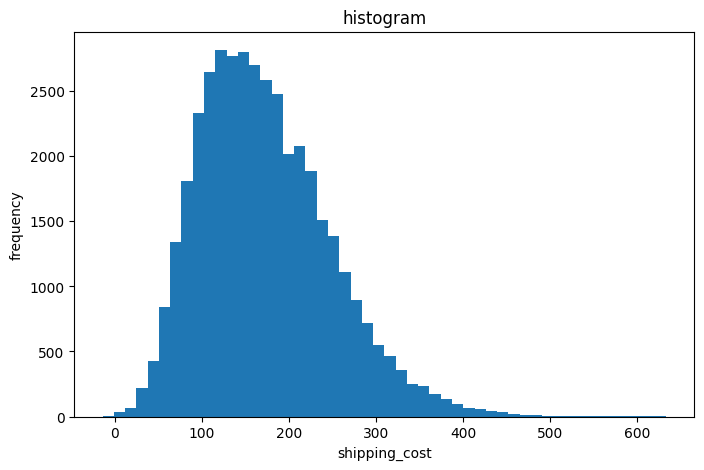

In [38]:
print("mean",orders["shipping_cost"].mean())
print("median",orders["shipping_cost"].median())
print("std",orders["shipping_cost"].std())
plt.figure(figsize=(8,5))
plt.hist(orders["shipping_cost"], bins=50)
plt.title("histogram")
plt.xlabel("shipping_cost")
plt.ylabel("frequency")
plt.show()

In [36]:
#2. Simulate the courtroom: flip a fair coin 400 times in NumPy, 1000 experiments. How often does 'heads rate' exceed 53% by luck alone? Relate this to the retention example.

In [42]:
import numpy as np
rng = np.random.default_rng(42)
flips = rng.integers(0, 2, size=(1000, 400))
heads_rate = flips.mean(axis=1)
count = np.sum(heads_rate > 0.53)
print("Experiments with >53% heads:", count)
print("Percentage:", (count / 1000) * 100, "%")

Experiments with >53% heads: 104
Percentage: 10.4 %
